## Practice Lab: Linear Regression

## 1 - Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math
%matplotlib inline

In [2]:
X_train, y_train = load_data()

## View the variables

In [3]:
print("type of x_train =",(type(X_train)))
print("print first five elements = ",X_train[:5])

type of x_train = <class 'numpy.ndarray'>
print first five elements =  [6.1101 5.5277 8.5186 7.0032 5.8598]


In [4]:
print("type of y_train = ", type(y_train))
print("first five elements in y_train = ", y_train[:5])

type of y_train =  <class 'numpy.ndarray'>
first five elements in y_train =  [17.592   9.1302 13.662  11.854   6.8233]


In [5]:
print("shape of X_train is =  ", X_train.shape)
print ("shape of y_train is = ", y_train.shape)
print("no. training example (m)= ",len(X_train) )

shape of X_train is =   (97,)
shape of y_train is =  (97,)
no. training example (m)=  97


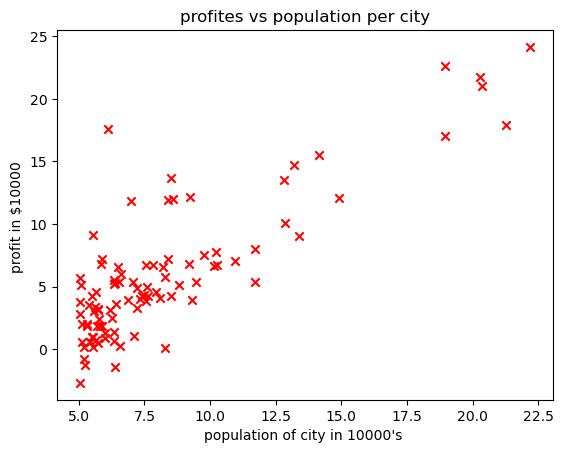

In [6]:
plt.scatter(X_train, y_train , marker = 'x', c = 'r')
plt.title ("profites vs population per city")
plt.ylabel("profit in $10000 ")
plt.xlabel("population of city in 10000's ")
plt.show()

In [7]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    total_cost = 0.0
    for i in range (m):
        f_wb = np.dot(X[i],w) + b
        cost =(f_wb - y[i]) ** 2
        total_cost = total_cost + cost
    total_cost = 1/(2 * m) * total_cost
    return total_cost

In [8]:
init_w = 2
init_b = 1
cost = compute_cost(X_train, y_train, init_w, init_b)
print(type(cost))
print(f'cost of initial w : {cost:.3f}' )

from public_tests import *
compute_cost_test(compute_cost)

<class 'numpy.float64'>
cost of initial w : 75.203
All tests passed!


In [9]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        dj_dw_i = (f_wb - y[i]) * X[i]
        dj_db_i = f_wb - y[i]

        dj_dw += dj_dw_i
        dj_db += dj_db_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


In [10]:
w_init = 0
b_init = 0
tmp_dj_dw,tmp_dj_db = compute_gradient(X_train, y_train, w_init, b_init)
print("gradient at init w, b :(zeros) = ", tmp_dj_dw, tmp_dj_db)
compute_gradient_test(compute_gradient)

gradient at init w, b :(zeros) =  -65.32884974555672 -5.83913505154639
Using X with shape (4, 1)
All tests passed!


In [11]:
test_w = 0.2
test_b = 0.2
tmp_dj_dw, tmp_dj_db = compute_gradient(X_train, y_train, test_w, test_b)
print("Gradient at test w, b = ", tmp_dj_dw, tmp_dj_db)

Gradient at test w, b =  -47.41610118114435 -4.007175051546391


In [14]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    m = len[X]

    J_history = []
    w_history = []
    w = copy.deepcopy[w_in]
    b = b_in

    for i in range (num_iters):
        dj_dw, dj_db = gradient_function(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 10000:
            cost = cost_function(X, y, w, b)

        if i% math.ceil(num_iters/10) == 0:
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w, b, J_history, w_history 


In [15]:
initial_w = 0.
initial_b = 0.


iterations = 1500
alpha = 0.01

w,b,_,_ = gradient_descent(X_train ,y_train, initial_w, initial_b, 
                     compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

TypeError: 'builtin_function_or_method' object is not subscriptable